In [44]:
import pandas as pd
import matplotlib.pyplot as plt

GWA, IWA, and DWA are defined in https://www.onetcenter.org/dl_files/DWA_2014.pdf Here are examples and images to give a background.
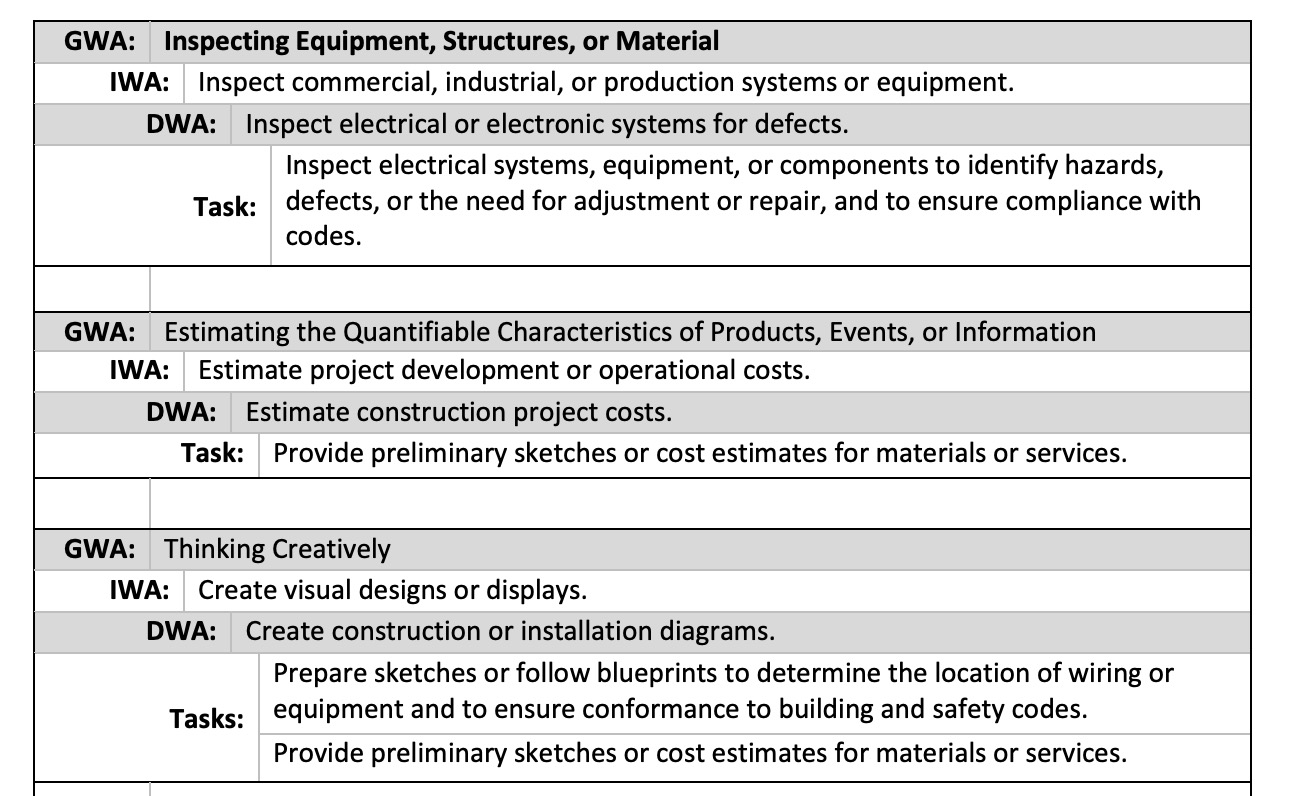
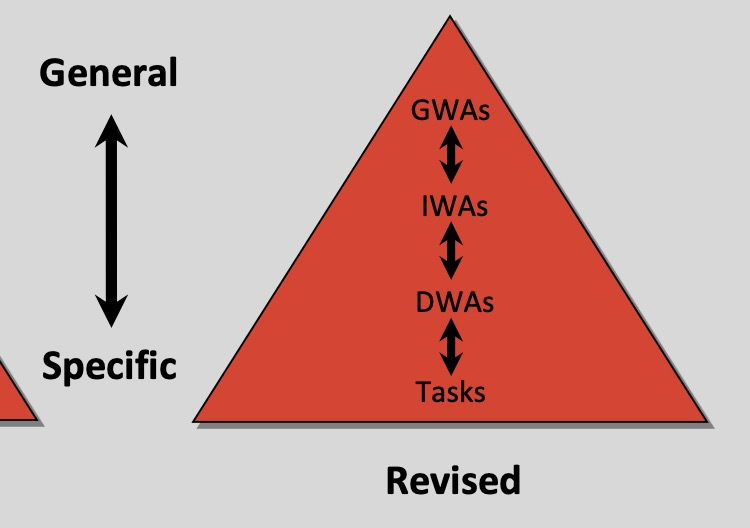

# Looking at the Importance and Level of the Work Activities to the Jobs

In [71]:
# get the augmentables
mca_df = pd.read_csv('../data/FINAL_mca_data.csv')
#augmented_df = mca_df[mca_df['AI Risk Classification'] == 'Augmented'].copy()

gwa_df = pd.read_csv('../data/ai_measurements/work_activities.csv')
gwa_df = gwa_df.pivot(
    index=['O*NET-SOC Code', 'Element ID', 'Element Name'],
    columns='Scale Name',
    values='Data Value'
).reset_index().rename(columns={'O*NET-SOC Code':'SOC Code'})

mca_df = mca_df.merge(gwa_df, how='left', on='SOC Code')


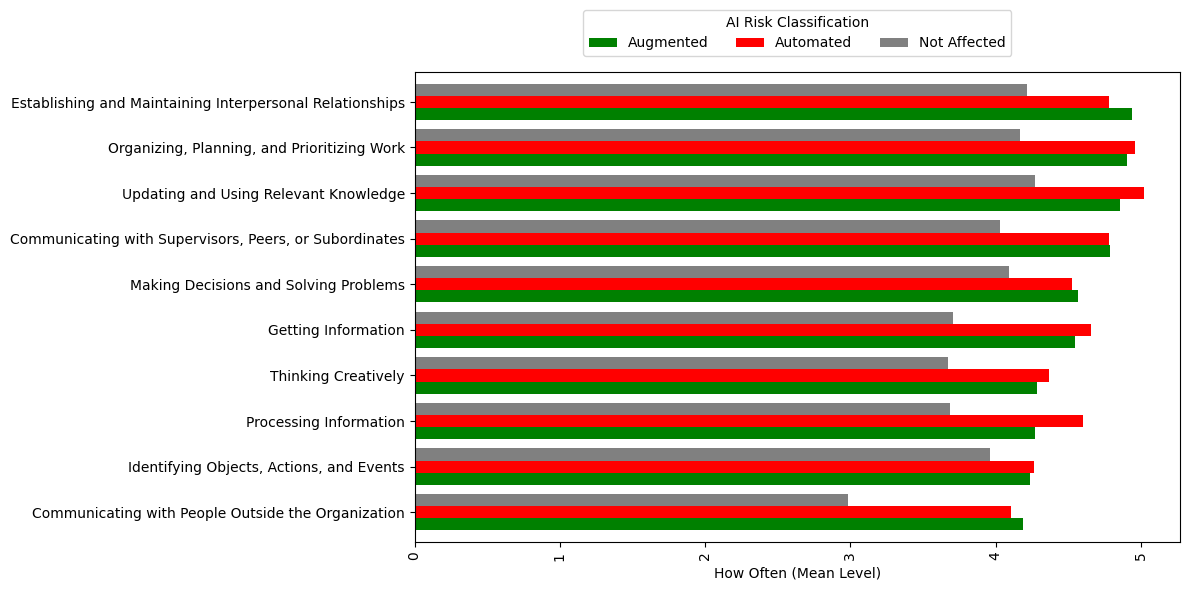

In [99]:
gwa_summary = (
    mca_df
    .groupby(['Element Name', 'AI Risk Classification'])[['Importance', 'Level']]
    .mean()
)

# Order GWAs based on Augmented Level, highest → lowest
gwa_order = (
    gwa_summary
    .xs('Augmented', level='AI Risk Classification')['Level']
    .sort_values(ascending=False)
    .index
)

# Plot
fig, ax = plt.subplots(figsize=(12, 6))

gwa_summary = gwa_summary.reindex(
    pd.MultiIndex.from_product(
        [
            gwa_order,
            ['Augmented', 'Automated', 'Not Affected']
        ],
        names=['Element Name', 'AI Risk Classification']
    )
)

# Plot only Level
top_n=10
level_data = gwa_summary['Level'].unstack().sort_values(by='Augmented', ascending=False)[::-1][-top_n:]

level_data.plot(
    kind='barh',
    ax=ax,
    width=0.8,
    color={
        'Augmented': 'green',
        'Automated': 'red',
        'Not Affected': 'gray'
    }
)

#ax.set_xlabel('Generalized Work Activity')
ax.set_xlabel('How Often (Mean Level)')
ax.set_ylabel('')
#ax.set_title('Mean Work Activity Level by AI Risk Classification')
ax.legend(title='AI Risk Classification')

ax.legend(
    title='AI Risk Classification',
    loc='lower center',
    bbox_to_anchor=(0.5, 1.02),
    ncol=3
)

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

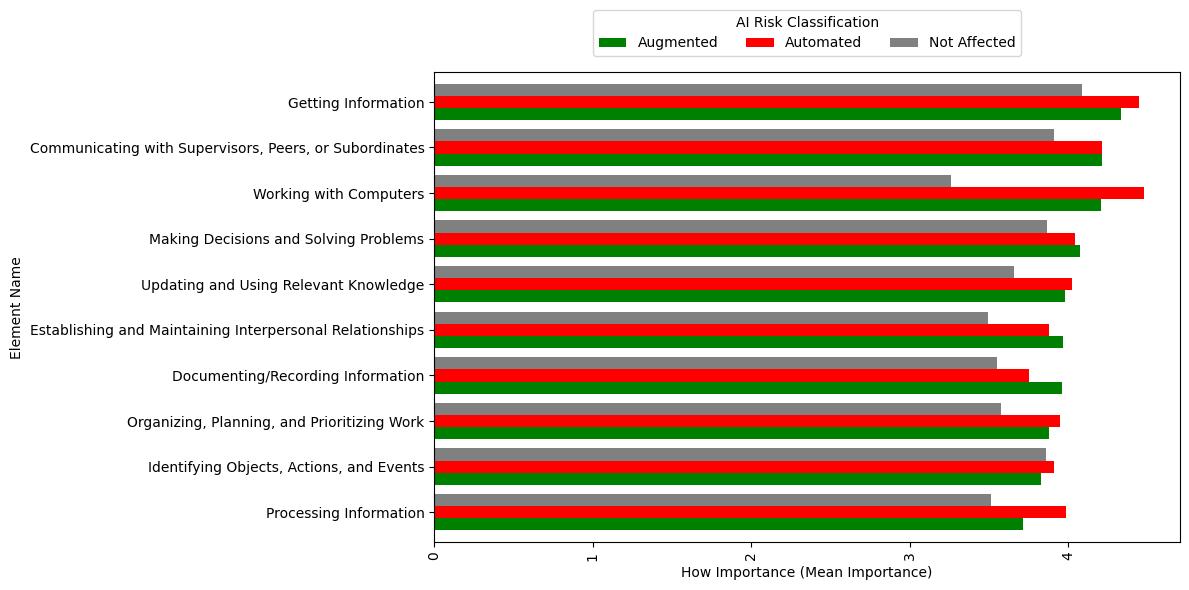

In [104]:
# Plot only Level
level_data = gwa_summary['Importance'].unstack().sort_values(by='Augmented', ascending=False)[::-1][-top_n:]

fig, ax = plt.subplots(figsize=(12, 6))
level_data.plot(
    kind='barh',
    ax=ax,
    width=0.8,
    color={
        'Augmented': 'green',
        'Automated': 'red',
        'Not Affected': 'gray'
    }
)

#ax.set_xlabel('Generalized Work Activity')
ax.set_xlabel('How Importance (Mean Importance)')
#ax.set_title('Mean Work Activity Level by AI Risk Classification')
ax.legend(title='AI Risk Classification')

ax.legend(
    title='AI Risk Classification',
    loc='lower center',
    bbox_to_anchor=(0.5, 1.02),
    ncol=3
)

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()